# Plot: S27 Elimination Timeline Case Study


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

PAPER_RC = {
    # Font sizes
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "figure.titlesize": 12,

    # Figure settings
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.figsize": (6.5, 3.5),

    # Style
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.axisbelow": True,

    # Font family
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
}

def apply_paper_style():
    """Apply paper-ready matplotlib style."""
    plt.rcParams.update(PAPER_RC)

apply_paper_style()


In [2]:
# =========================
# 1) 路径与配置
# =========================
# 默认从 notebooks/26Feb2-mcm 目录运行
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
DATA_DIR = os.path.join(BASE_DIR, "data", "26Feb2-mcm")
FIGDIR = os.path.join(BASE_DIR, "figures", "26Feb2-mcm", "12_s27_elimination_timeline")

# LaTeX single-column figure sizes
FIGSIZE_STANDARD = (6.5, 3.5)
FIGSIZE_WIDE = (6.5, 2.8)
FIGSIZE_TALL = (6.5, 4.5)
FIGSIZE_DUAL = (8.6, 3.2)
DPI = 300

FIGSIZE = FIGSIZE_TALL

SEASON = 27
MAX_WEEK = 11
ACTIVE_EPS = 1e-12

DATA_CSV = os.path.join(DATA_DIR, "task2", "inferred_votes_long.csv")
OUT_PDF = os.path.join(FIGDIR, "s27_elimination_timeline.pdf")

os.makedirs(FIGDIR, exist_ok=True)


In [3]:
# -------------------------
# utils
# -------------------------

def pick_col(df: pd.DataFrame, candidates: list[str], required: bool = True) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"找不到列（候选：{candidates}），实际列名：{list(df.columns)}")
    return None


def active_mask(df: pd.DataFrame, j_col: str, v_col: str) -> np.ndarray:
    j = df[j_col].to_numpy(float)
    v = df[v_col].to_numpy(float)
    return (j > ACTIVE_EPS) | (v > ACTIVE_EPS)


def prepare_long_df(data_path: str, season: int, max_week: int) -> pd.DataFrame:
    df = pd.read_csv(data_path, encoding="utf-8-sig")

    season_col = pick_col(df, ["season", "Season"])
    week_col = pick_col(df, ["week", "Week"])
    name_col = pick_col(df, ["celebrity_name", "name", "Celebrity"])
    j_col = pick_col(df, ["J_pct", "J_tilde", "J_share", "judge_pct", "judge_share"])
    v_col = pick_col(df, ["V_hat", "V_tilde_hat", "V_tilde", "vote_hat", "vote_share", "V_share"])
    elim_col = pick_col(df, ["is_eliminated_this_week", "eliminated"], required=True)

    df[season_col] = pd.to_numeric(df[season_col], errors="coerce").astype("Int64")
    df[week_col] = pd.to_numeric(df[week_col], errors="coerce").astype("Int64")
    df[j_col] = pd.to_numeric(df[j_col], errors="coerce").fillna(0.0)
    df[v_col] = pd.to_numeric(df[v_col], errors="coerce").fillna(0.0)
    df[elim_col] = pd.to_numeric(df[elim_col], errors="coerce").fillna(0).astype(int)

    d = df[(df[season_col] == season) & (df[week_col] >= 1) & (df[week_col] <= max_week)].copy()
    if d.empty:
        raise ValueError(f"没有 season={season} 的数据。")

    d = d.loc[active_mask(d, j_col, v_col)].copy()

    d = d.rename(columns={
        season_col: "season",
        week_col: "week",
        name_col: "celebrity_name",
        j_col: "J_pct",
        v_col: "V_hat",
        elim_col: "is_eliminated_this_week",
    })
    return d


# -------------------------
# plotting
# -------------------------

def plot_s27_elimination_timeline(data_path: str, output_path: str, season: int = SEASON, max_week: int = MAX_WEEK):
    """Generate S27 elimination timeline plot."""
    d = prepare_long_df(data_path, season=season, max_week=max_week)

    s27 = d[d["is_eliminated_this_week"] == 1].copy()
    s27 = s27.sort_values("week")

    fig, ax = plt.subplots(figsize=FIGSIZE)

    weeks = s27["week"].to_numpy()
    names = s27["celebrity_name"].to_list()
    v_hats = s27["V_hat"].to_numpy()

    ax.barh(range(len(names)), weeks, color="#4C78A8", edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel("Elimination Week")
    fig.suptitle("Season 27: Elimination Timeline", x=0.48, y=0.97, ha="center", fontsize=12, fontweight="bold")

    for i, (w, v) in enumerate(zip(weeks, v_hats)):
        ax.text(w + 0.1, i, f"V={v:.2f}", va="center", fontsize=7)

    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


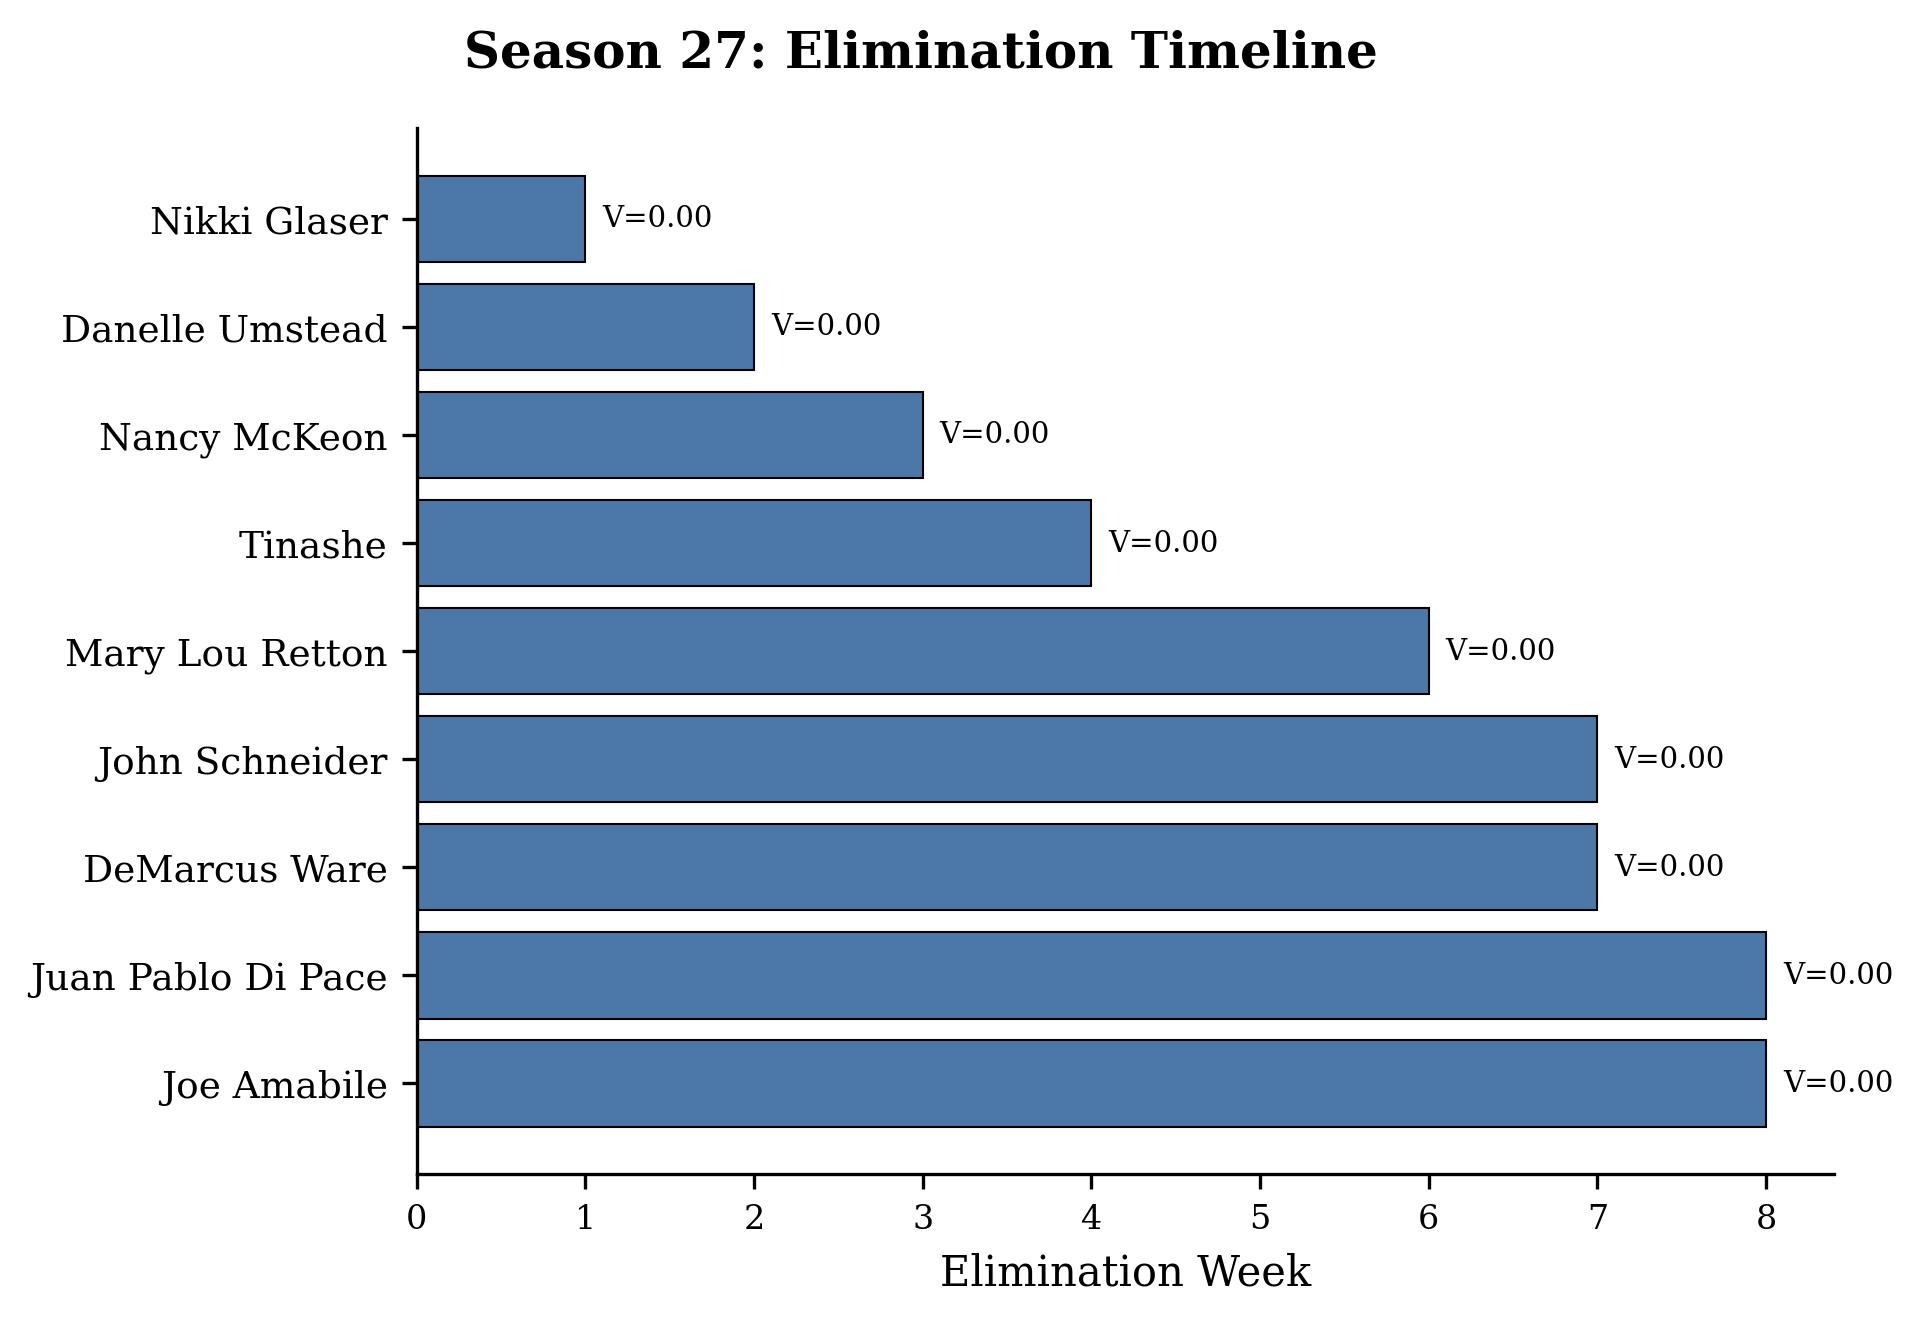

Saved: /home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/12_s27_elimination_timeline/s27_elimination_timeline.pdf
Saved: /home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/12_s27_elimination_timeline/s27_elimination_timeline.pdf


In [4]:
plot_s27_elimination_timeline(DATA_CSV, OUT_PDF)
print("Saved:", OUT_PDF)
